<a href="https://colab.research.google.com/github/Zarrialvi/Airport-Recognition-system/blob/main/Air_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install pandas matplotlib seaborn tabulate ipywidgets plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
from tabulate import tabulate
import warnings, random, json, hashlib, uuid
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

warnings.filterwarnings('ignore')

C = {
    "bg":      "#0a0f1e",
    "surface": "#0d1730",
    "card":    "#111827",
    "accent":  "#00d4ff",
    "green":   "#00ff88",
    "red":     "#ff4466",
    "yellow":  "#ffcc00",
    "orange":  "#ff8800",
    "purple":  "#a855f7",
    "text":    "#e2e8f0",
    "muted":   "#64748b",
}

plt.rcParams.update({
    'figure.facecolor': C['bg'],
    'axes.facecolor':   C['surface'],
    'axes.edgecolor':   C['muted'],
    'axes.labelcolor':  C['text'],
    'xtick.color':      C['muted'],
    'ytick.color':      C['muted'],
    'text.color':       C['text'],
    'grid.color':       '#1e2d4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})

print(" All dependencies loaded successfully!")
print(f"    Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"    System    : AirsecID v1.0")
print(f"    Status    : GDPR COMPLIANT · EDPB Opinion 11/2024")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.5 MB/s eta 0:00:00
 All dependencies loaded successfully!
    Timestamp : 2026-02-18 15:21:09
    System    : AirsecID v1.0
    Status    : GDPR COMPLIANT · EDPB Opinion 11/2024


In [ ]:
#  DATA MODELS


class PassengerDB:
    """In-memory GDPR-compliant passenger database."""

    def __init__(self):
        self.records = {}
        self.audit_log = []
        self._seed_data()

    def _seed_data(self):
        seeds = [
            ("P001","Alice Martin",   "LH470","S1","enrolled",  "2026-02-15"),
            ("P002","Bob Chen",        "EK202","S2","authenticated","2026-02-16"),
            ("P003","Fatima Al-Hassan","QR007","S1","enrolled",  "2026-02-17"),
            ("P004","Carlos Ruiz",     "BA115","S2","pending",   "2026-02-17"),
            ("P005","Emma Schmidt",    "AF890","S1","authenticated","2026-02-18"),
            ("P006","James Okafor",    "TK008","S2","enrolled",  "2026-02-18"),
            ("P007","Yuki Tanaka",     "NH201","S1","authenticated","2026-02-18"),
            ("P008","Priya Sharma",    "AI304","S2","enrolled",  "2026-02-18"),
        ]
        for pid,name,flight,scenario,status,enrolled in seeds:
            self.records[pid] = {
                "id": pid, "name": name, "flight": flight,
                "scenario": scenario, "status": status,
                "enrolled": enrolled, "consent": True,
                "deleted": False,
                "template_hash": hashlib.sha256(name.encode()).hexdigest()[:16],
                "retention": "post-auth" if scenario=="S1" else "48h-post-flight",
            }
            self._log("SEED_ENROLLMENT", pid, "System", "Kiosk", "SUCCESS")

    def _log(self, event, pid, operator, location, result):
        self.audit_log.append({
            "log_id":    f"L{len(self.audit_log)+1:04d}",
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "event":     event,
            "passenger": pid,
            "operator":  operator,
            "location":  location,
            "result":    result,
        })

    def enroll(self, name, flight, scenario, consent):
        if not consent:
            return None, "  Enrollment requires explicit passenger consent."
        if scenario not in ("S1","S2"):
            return None, " Only GDPR-compliant Scenarios 1 & 2 are permitted."
        pid = f"P{len(self.records)+100:03d}"
        self.records[pid] = {
            "id": pid, "name": name, "flight": flight,
            "scenario": scenario, "status": "enrolled",
            "enrolled": datetime.now().strftime("%Y-%m-%d"),
            "consent": True, "deleted": False,
            "template_hash": hashlib.sha256(name.encode()).hexdigest()[:16],
            "retention": "post-auth" if scenario=="S1" else "48h-post-flight",
        }
        self._log("ENROLLMENT", pid, "OPS", "Kiosk", "SUCCESS")
        return pid, f" Passenger {name} enrolled with ID {pid}"

    def authenticate(self, pid):
        p = self.records.get(pid)
        if not p or p["deleted"]:
            return " Passenger not found or data deleted."
        p["status"] = "authenticated"
        self._log("AUTHENTICATION", pid, "OPS01", "Gate", "SUCCESS")
        return f" {p['name']} authenticated successfully via Scenario {p['scenario']}"

    def delete(self, pid):
        p = self.records.get(pid)
        if not p:
            return "  Passenger not found."
        p["deleted"] = True; p["status"] = "deleted"
        p["template_hash"] = "CRYPTOGRAPHIC_KEY_DESTROYED"
        self._log("DELETION", pid, "DPO", "Admin", "SUCCESS")
        return f" Biometric data for {p['name']} securely deleted (GDPR Art. 17)"

    def dsar(self, pid):
        p = self.records.get(pid)
        if not p:
            return " Passenger not found."
        return {
            "Passenger ID":       p["id"],
            "Name":               p["name"],
            "Flight":             p["flight"],
            "Scenario":           p["scenario"],
            "Storage Location":   "Device only" if p["scenario"]=="S1" else "Encrypted Airport DB",
            "Retention Policy":   p["retention"],
            "Consent Given":      "Yes",
            "Data Deleted":       str(p["deleted"]),
            "Template Hash":      p["template_hash"],
            "DSAR Response SLA":  "30 days (GDPR Art. 17)",
            "DPO Contact":        "dpo@airport-biometrics.eu",
        }

    def to_df(self):
        return pd.DataFrame([
            {k: v for k,v in r.items() if k != "template_hash"}
            for r in self.records.values()
        ])

    def audit_df(self):
        return pd.DataFrame(self.audit_log)


# ── Instantiate global DB ────────────────────────────────────────────────
db = PassengerDB()
print("Database initialised with", len(db.records), "passengers")
print("Audit log seeded with",     len(db.audit_log), "events")


Database initialised with 8 passengers
Audit log seeded with 8 events


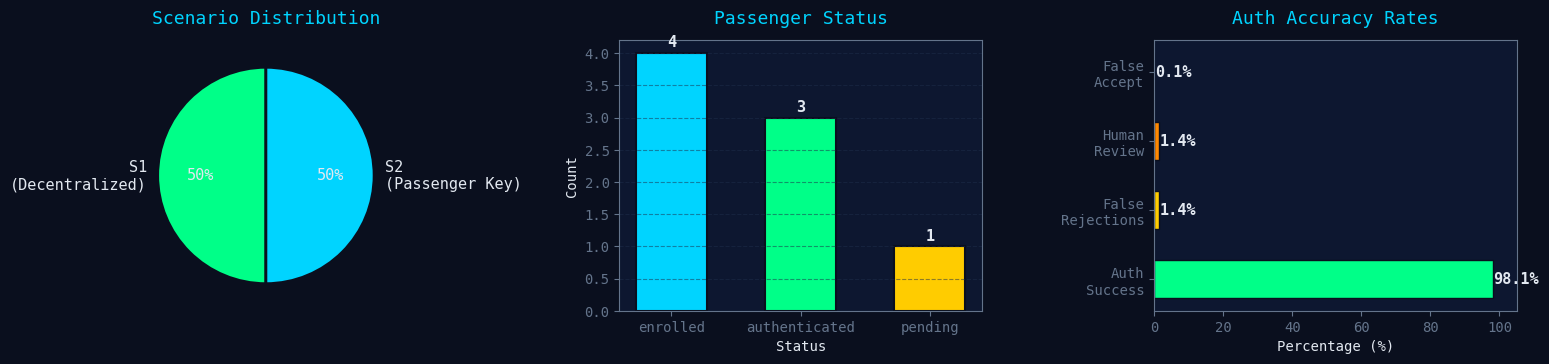


✅  Dashboard rendered successfully.


In [ ]:
def show_dashboard():
    df = db.to_df()
    total     = len(df)
    enrolled  = len(df[df.status=="enrolled"])
    authed    = len(df[df.status=="authenticated"])
    deleted   = len(df[df.deleted==True])
    s1_count  = len(df[df.scenario=="S1"])
    s2_count  = len(df[df.scenario=="S2"])

    display(HTML(f"""
    <style>
      .dash {{ background:#0a0f1e; padding:20px; border-radius:12px; font-family:monospace; }}
      .dash-title {{ color:#00d4ff; font-size:22px; font-weight:bold; letter-spacing:2px;
                     border-bottom:2px solid #1e2d4a; padding-bottom:10px; margin-bottom:20px; }}
      .metrics {{ display:flex; gap:14px; flex-wrap:wrap; margin-bottom:20px; }}
      .metric {{ background:#111827; border:1px solid #1e2d4a; border-radius:10px;
                 padding:16px 22px; min-width:150px; flex:1; }}
      .metric-label {{ color:#64748b; font-size:11px; text-transform:uppercase;
                        letter-spacing:1px; margin-bottom:6px; }}
      .metric-value {{ font-size:28px; font-weight:bold; }}
      .metric-sub   {{ color:#64748b; font-size:11px; margin-top:4px; }}
      .badge {{ display:inline-block; padding:3px 10px; border-radius:12px;
                font-size:11px; font-weight:bold; margin:2px; }}
      .green  {{ background:#00ff8822; border:1px solid #00ff8844; color:#00ff88; }}
      .blue   {{ background:#00d4ff22; border:1px solid #00d4ff44; color:#00d4ff; }}
      .yellow {{ background:#ffcc0022; border:1px solid #ffcc0044; color:#ffcc00; }}
      .red    {{ background:#ff446622; border:1px solid #ff446644; color:#ff4466; }}
      .purple {{ background:#a855f722; border:1px solid #a855f744; color:#a855f7; }}
    </style>
    <div class='dash'>
      <div class='dash-title'>✈️  AIRSECID — SYSTEM DASHBOARD &nbsp;
        <span class='badge green'>GDPR COMPLIANT</span>
        <span class='badge blue'>EDPB Opinion 11/2024</span>
        <span class='badge green'>● OPERATIONAL</span>
      </div>
      <div class='metrics'>
        <div class='metric'>
          <div class='metric-label'>Total Passengers</div>
          <div class='metric-value' style='color:#00d4ff'>{total}</div>
          <div class='metric-sub'>Enrolled in system</div>
        </div>
        <div class='metric'>
          <div class='metric-label'>Authenticated Today</div>
          <div class='metric-value' style='color:#00ff88'>{authed}</div>
          <div class='metric-sub'>Scenario 1 & 2</div>
        </div>
        <div class='metric'>
          <div class='metric-label'>Scenario 1 (S1)</div>
          <div class='metric-value' style='color:#00ff88'>{s1_count}</div>
          <div class='metric-sub'>Device-only storage</div>
        </div>
        <div class='metric'>
          <div class='metric-label'>Scenario 2 (S2)</div>
          <div class='metric-value' style='color:#00d4ff'>{s2_count}</div>
          <div class='metric-sub'>Central + Passenger Key</div>
        </div>
        <div class='metric'>
          <div class='metric-label'>Data Deletions</div>
          <div class='metric-value' style='color:#a855f7'>{deleted}</div>
          <div class='metric-sub'>GDPR Art. 17 erasures</div>
        </div>
        <div class='metric'>
          <div class='metric-label'>Security Alerts</div>
          <div class='metric-value' style='color:#ffcc00'>1</div>
          <div class='metric-sub'>1 false alarm resolved</div>
        </div>
      </div>
      <div style='color:#64748b; font-size:12px;'>
        🕐 Last updated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")} &nbsp;|&nbsp;
        🔐 Encryption: AES-256 / HSM &nbsp;|&nbsp;
        👔 DPO: dpo@airport-biometrics.eu &nbsp;|&nbsp;
        📋 Audit logs: {len(db.audit_log)} events
      </div>
    </div>
    """))

    # ── Charts ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.patch.set_facecolor(C['bg'])

    # Pie – Scenario split
    ax = axes[0]
    ax.pie([s1_count, s2_count], labels=["S1\n(Decentralized)", "S2\n(Passenger Key)"],
           colors=[C['green'], C['accent']], autopct='%1.0f%%',
           textprops={'color': C['text'], 'fontsize': 11},
           wedgeprops={'edgecolor': C['bg'], 'linewidth': 2}, startangle=90)
    ax.set_title("Scenario Distribution", color=C['accent'], pad=12, fontsize=13)

    # Bar – Passenger status
    ax = axes[1]
    statuses = df['status'].value_counts()
    colors_map = {"enrolled": C['accent'], "authenticated": C['green'],
                  "pending": C['yellow'], "deleted": C['red']}
    bars = ax.bar(statuses.index, statuses.values,
                  color=[colors_map.get(s, C['muted']) for s in statuses.index],
                  edgecolor=C['bg'], linewidth=1.5, width=0.55)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, str(int(b.get_height())),
                ha='center', va='bottom', color=C['text'], fontsize=11, fontweight='bold')
    ax.set_title("Passenger Status", color=C['accent'], pad=12, fontsize=13)
    ax.set_xlabel("Status"); ax.set_ylabel("Count"); ax.grid(axis='y')

    # Gauge-style bar – Auth success rate
    ax = axes[2]
    categories = ['Auth\nSuccess', 'False\nRejections', 'Human\nReview', 'False\nAccept']
    values      = [98.1, 1.4, 1.4, 0.1]
    bar_colors  = [C['green'], C['yellow'], C['orange'], C['red']]
    bars = ax.barh(categories, values, color=bar_colors, edgecolor=C['bg'], height=0.55)
    for b in bars:
        w = b.get_width()
        ax.text(w + 0.2, b.get_y()+b.get_height()/2, f"{w}%",
                va='center', color=C['text'], fontsize=11, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.set_title("Auth Accuracy Rates", color=C['accent'], pad=12, fontsize=13)
    ax.set_xlabel("Percentage (%)")

    plt.tight_layout(pad=2)
    plt.savefig("dashboard.png", dpi=120, bbox_inches='tight', facecolor=C['bg'])
    plt.show()
    print("\n✅  Dashboard rendered successfully.")

show_dashboard()


In [ ]:
def show_passengers(filter_by=None):
    df = db.to_df()
    if filter_by:
        df = df[df['status']==filter_by]

    def style_scenario(v):
        color = "#00ff88" if v=="S1" else "#00d4ff"
        return f"<span style='background:{color}22;border:1px solid {color}44;color:{color};padding:2px 8px;border-radius:10px;font-size:11px;font-weight:bold'>{v}</span>"

    def style_status(v):
        color = {"enrolled":"#00d4ff","authenticated":"#00ff88","pending":"#ffcc00","deleted":"#ff4466"}.get(v,"#64748b")
        return f"<span style='background:{color}22;border:1px solid {color}44;color:{color};padding:2px 8px;border-radius:10px;font-size:11px;font-weight:bold'>{v}</span>"

    rows = ""
    for _, r in df.iterrows():
        rows += f"<tr style='border-bottom:1px solid #1e2d4a22; opacity:{'0.4' if r['deleted'] else '1'}'>"
        rows += f"<td style='padding:10px 14px;font-family:monospace;color:#64748b;font-size:12px'>{r['id']}</td>"
        rows += f"<td style='padding:10px 14px;font-weight:bold;color:#e2e8f0'>{r['name']}</td>"
        rows += f"<td style='padding:10px 14px;color:#94a3b8'>{r['flight']}</td>"
        rows += f"<td style='padding:10px 14px'>{style_scenario(r['scenario'])}</td>"
        rows += f"<td style='padding:10px 14px'>{style_status(r['status'])}</td>"
        rows += f"<td style='padding:10px 14px;color:#64748b;font-size:12px'>{r['enrolled']}</td>"
        rows += f"<td style='padding:10px 14px;color:#94a3b8'>{r['retention']}</td>"
        rows += "</tr>"

    display(HTML(f"""
    <style>
      .pt {{background:#0a0f1e;padding:20px;border-radius:12px;font-family:monospace;overflow-x:auto}}
      .pt table {{width:100%;border-collapse:collapse;font-size:13px}}
      .pt th {{padding:10px 14px;text-align:left;font-size:11px;color:#64748b;text-transform:uppercase;
               letter-spacing:.08em;border-bottom:1px solid #1e2d4a;background:#0d1730}}
    </style>
    <div class='pt'>
      <div style='color:#00d4ff;font-size:16px;font-weight:bold;margin-bottom:14px'>
        👤 PASSENGER REGISTRY &nbsp;
        <span style='font-size:12px;color:#64748b'>{len(df)} records shown</span>
      </div>
      <table>
        <tr>
          {''.join(f"<th>{h}</th>" for h in ['ID','Name','Flight','Scenario','Status','Enrolled','Retention'])}
        </tr>
        {rows}
      </table>
    </div>
    """))

show_passengers()


ID,Name,Flight,Scenario,Status,Enrolled,Retention
P001,Alice Martin,LH470,S1,authenticated,2026-02-15,post-auth
P002,Bob Chen,EK202,S2,authenticated,2026-02-16,48h-post-flight
P003,Fatima Al-Hassan,QR007,S1,deleted,2026-02-17,post-auth
P004,Carlos Ruiz,BA115,S2,pending,2026-02-17,48h-post-flight
P005,Emma Schmidt,AF890,S1,authenticated,2026-02-18,post-auth
P006,James Okafor,TK008,S2,enrolled,2026-02-18,48h-post-flight
P007,Yuki Tanaka,NH201,S1,authenticated,2026-02-18,post-auth
P008,Priya Sharma,AI304,S2,enrolled,2026-02-18,48h-post-flight
P108,Sara Khan,PK301,S1,enrolled,2026-02-18,post-auth


In [ ]:
passenger_name   = "Sara Khan"
flight_number    = "PK301"
storage_scenario = "S1"
gdpr_consent     = True

pid, message = db.enroll(passenger_name, flight_number, storage_scenario, gdpr_consent)
print(message)
if pid:
    print(f"   Passenger ID    : {pid}")
    print(f"   Scenario        : {storage_scenario}")
    print(f"   Retention       : {'post-auth deletion' if storage_scenario=='S1' else '48h post-flight'}")
    print(f"   Template Hash   : {db.records[pid]['template_hash']}")
    print(f"   GDPR Art. 9     : Special category biometric — explicit consent logged")


 Passenger Sara Khan enrolled with ID P108
   Passenger ID    : P108
   Scenario        : S1
   Retention       : post-auth deletion
   Template Hash   : 1ebc96ebc0d1e2ea
   GDPR Art. 9     : Special category biometric — explicit consent logged


In [ ]:
authenticate_id = "P001"   # ← Passenger ID to authenticate

result = db.authenticate(authenticate_id)
print(result)


 Alice Martin authenticated successfully via Scenario S1


In [ ]:
dsar_id = "P002"   # ← Passenger ID requesting DSAR

info = db.dsar(dsar_id)
display(HTML(f"""
<div style='background:#0a0f1e;border:1px solid #00d4ff44;border-radius:10px;padding:20px;font-family:monospace;max-width:600px'>
  <div style='color:#00d4ff;font-size:16px;font-weight:bold;margin-bottom:16px'>
    📋 DATA SUBJECT ACCESS REQUEST — GDPR Art. 15
  </div>
  {''.join(f"<div style='display:flex;gap:12px;padding:7px 0;border-bottom:1px solid #1e2d4a22;font-size:13px'><span style='color:#64748b;width:200px;flex-shrink:0'>{k}</span><span style='color:#e2e8f0'>{v}</span></div>" for k,v in info.items())}
  <div style='margin-top:14px;font-size:11px;color:#64748b'>Response must be provided within 30 days (GDPR Art. 17) &nbsp;|&nbsp; DPO: dpo@airport-biometrics.eu</div>
</div>
"""))


In [ ]:
delete_id = "P003"   # ← Passenger ID requesting deletion

result = db.delete(delete_id)
print(result)
print("   Method : Cryptographic key destruction + secure overwrite")
print("   Logged : Yes — audit trail maintained (without biometric data)")


 Biometric data for Fatima Al-Hassan securely deleted (GDPR Art. 17)
   Method : Cryptographic key destruction + secure overwrite
   Logged : Yes — audit trail maintained (without biometric data)


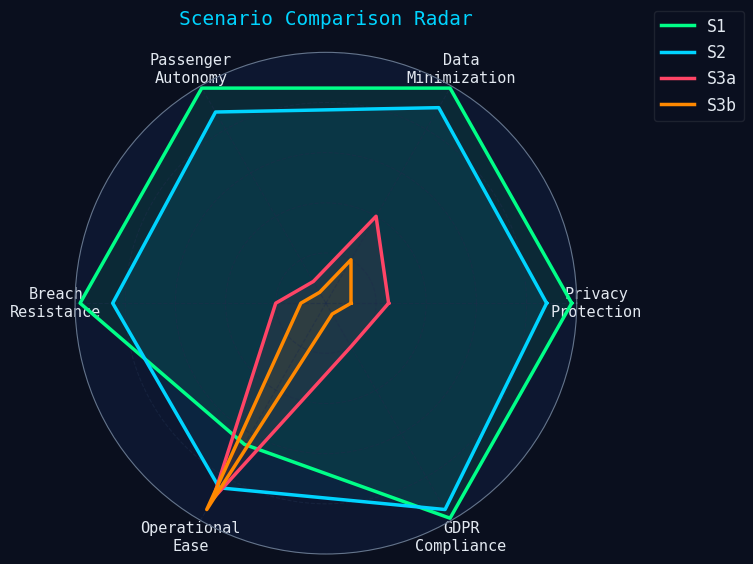

In [ ]:
scenarios = [
    {
        "id":"S1","name":"Decentralized Passenger-Controlled",
        "compliant":True, "gdpr":"✅ Compliant",
        "storage":"Passenger Device Only","auth":"1:1 Offline",
        "retention":"Deleted after each auth","control":"Full",
        "articles":["Art.5(1)(f)","Art.25","Art.32"],
        "pros":["No central DB — no catastrophic breach",
                "Maximum passenger autonomy","Offline matching",
                "EDPB Opinion 11/2024 — Compliant"],
        "cons":["Requires app pre-download","Lower spontaneous adoption","Device-dependent"],
        "safeguards":["AES-256 on-device","iOS Keychain/Android Keystore","Instant post-auth deletion"],
    },
    {
        "id":"S2","name":"Passenger-Held Key Centralized",
        "compliant":True, "gdpr":"✅ Compliant",
        "storage":"Airport Central DB (Encrypted)","auth":"1:1 Key-Unlocked",
        "retention":"48h–1yr (passenger-adjustable)","control":"High",
        "articles":["Art.5(1)(e)","Art.5(1)(f)","Art.25","Art.32"],
        "pros":["No app download needed","Passenger holds decryption keys",
                "Breach yields only encrypted data","Airport kiosk enrollment"],
        "cons":["Central DB risk if keys compromised","Complex key management","PIN-based keys can be weak"],
        "safeguards":["AES-256 centralized","HSM key management","eIDAS identity verification",
                      "Auto deletion schedule","Passenger-adjustable retention"],
    },
    {
        "id":"S3a","name":"Centralized Airport (Operator Keys)",
        "compliant":False, "gdpr":"❌ Non-Compliant",
        "storage":"Central DB (Airport Keys)","auth":"1:N ID Search",
        "retention":"48 hours","control":"None",
        "articles":["Art.25 — FAIL","Art.5(1)(f) — FAIL"],
        "pros":["Operational convenience"],
        "cons":["Airport holds all keys — catastrophic breach exposure",
                "Fails necessity/proportionality","Enables function creep",
                "No passenger autonomy","Enforcement risk"],
        "safeguards":["PROHIBITED under this framework"],
    },
    {
        "id":"S3b","name":"Cloud Storage (Provider Keys)",
        "compliant":False, "gdpr":"❌ Non-Compliant",
        "storage":"Cloud (Airline/Vendor Keys)","auth":"1:N Continuous ID",
        "retention":"Indefinite","control":"None",
        "articles":["Art.5(1)(e) — FAIL","Art.25 — FAIL"],
        "pros":["Airline integration convenience"],
        "cons":["Indefinite retention violates storage limitation",
                "Multiple entities access data","Worst rights exposure",
                "EDPB: Strongly advise against"],
        "safeguards":["PROHIBITED under this framework"],
    },
]

def show_scenarios():
    html = """
    <style>
      .sc-grid{{display:grid;grid-template-columns:1fr 1fr;gap:16px;font-family:monospace}}
      .sc-card{{border-radius:10px;padding:20px;background:#111827}}
      .sc-title{{font-size:16px;font-weight:bold;color:#e2e8f0;margin-bottom:4px}}
      .sc-sub{{font-size:12px;color:#64748b;margin-bottom:14px}}
      .sc-row{{display:flex;gap:10px;margin-bottom:6px;font-size:12px}}
      .sc-key{{color:#64748b;width:140px;flex-shrink:0}}
      .sc-val{{color:#94a3b8}}
      .tag{{display:inline-block;padding:2px 8px;border-radius:4px;font-size:10px;font-weight:bold;margin:2px}}
      .sc-section{{margin-top:14px;padding-top:12px;border-top:1px solid #1e2d4a44}}
      .sc-section-title{{font-size:11px;font-weight:bold;letter-spacing:.08em;margin-bottom:6px}}
      li{{font-size:12px;color:#94a3b8;margin-bottom:4px;list-style:none;padding-left:12px}}
    </style>
    <div class='sc-grid'>
    """
    for s in scenarios:
        bc = "#00ff88" if s["compliant"] else "#ff4466"
        html += f"""
        <div class='sc-card' style='border:1px solid {bc}44'>
          <div style='display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:8px'>
            <div>
              <div style='font-size:11px;color:#64748b;letter-spacing:.1em;margin-bottom:4px'>SCENARIO {s['id']}</div>
              <div class='sc-title'>{s['name']}</div>
            </div>
            <span style='background:{bc}22;border:1px solid {bc}44;color:{bc};padding:4px 12px;
              border-radius:12px;font-size:12px;font-weight:bold'>{s['gdpr']}</span>
          </div>
          <div class='sc-row'><span class='sc-key'>Storage</span><span class='sc-val'>{s['storage']}</span></div>
          <div class='sc-row'><span class='sc-key'>Auth Method</span><span class='sc-val'>{s['auth']}</span></div>
          <div class='sc-row'><span class='sc-key'>Retention</span><span class='sc-val'>{s['retention']}</span></div>
          <div class='sc-row'><span class='sc-key'>Passenger Control</span><span class='sc-val'>{s['control']}</span></div>
          <div style='margin-top:10px'>
            {''.join(f"<span class='tag' style='background:{bc}22;color:{bc};border:1px solid {bc}33'>{a}</span>" for a in s['articles'])}
          </div>
          <div class='sc-section'>
            <div class='sc-section-title' style='color:#00ff88'>✓ ADVANTAGES</div>
            {''.join(f"<li style='color:#00ff8899'>• {p}</li>" for p in s['pros'])}
          </div>
          <div class='sc-section'>
            <div class='sc-section-title' style='color:#ff4466'>✗ RISKS / CONS</div>
            {''.join(f"<li style='color:#ff446699'>• {c}</li>" for c in s['cons'])}
          </div>
        </div>"""
    html += "</div>"
    display(HTML(html))

    # Radar chart
    categories = ["Privacy\nProtection","Data\nMinimization","Passenger\nAutonomy",
                  "Breach\nResistance","Operational\nEase","GDPR\nCompliance"]
    values_map = {
        "S1":  [98, 99, 99, 98, 65, 99],
        "S2":  [88, 90, 88, 85, 85, 95],
        "S3a": [25, 40, 10, 20, 90, 20],
        "S3b": [10, 20,  5, 10, 95,  5],
    }
    colors_map = {"S1":C['green'],"S2":C['accent'],"S3a":C['red'],"S3b":C['orange']}
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(C['bg']); ax.set_facecolor(C['surface'])
    ax.set_ylim(0,100); ax.set_yticks([20,40,60,80,100]); ax.set_yticklabels([])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, color=C['text'], size=11)
    ax.grid(color='#1e2d4a', linestyle='--', alpha=0.5)

    for s in scenarios:
        vals = values_map[s['id']] + [values_map[s['id']][0]]
        ax.plot(angles, vals, color=colors_map[s['id']], linewidth=2.5, label=s['id'])
        ax.fill(angles, vals, color=colors_map[s['id']], alpha=0.08)

    ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1), framealpha=0.1,
              labelcolor=C['text'], fontsize=12)
    ax.set_title("Scenario Comparison Radar", color=C['accent'], pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()

show_scenarios()


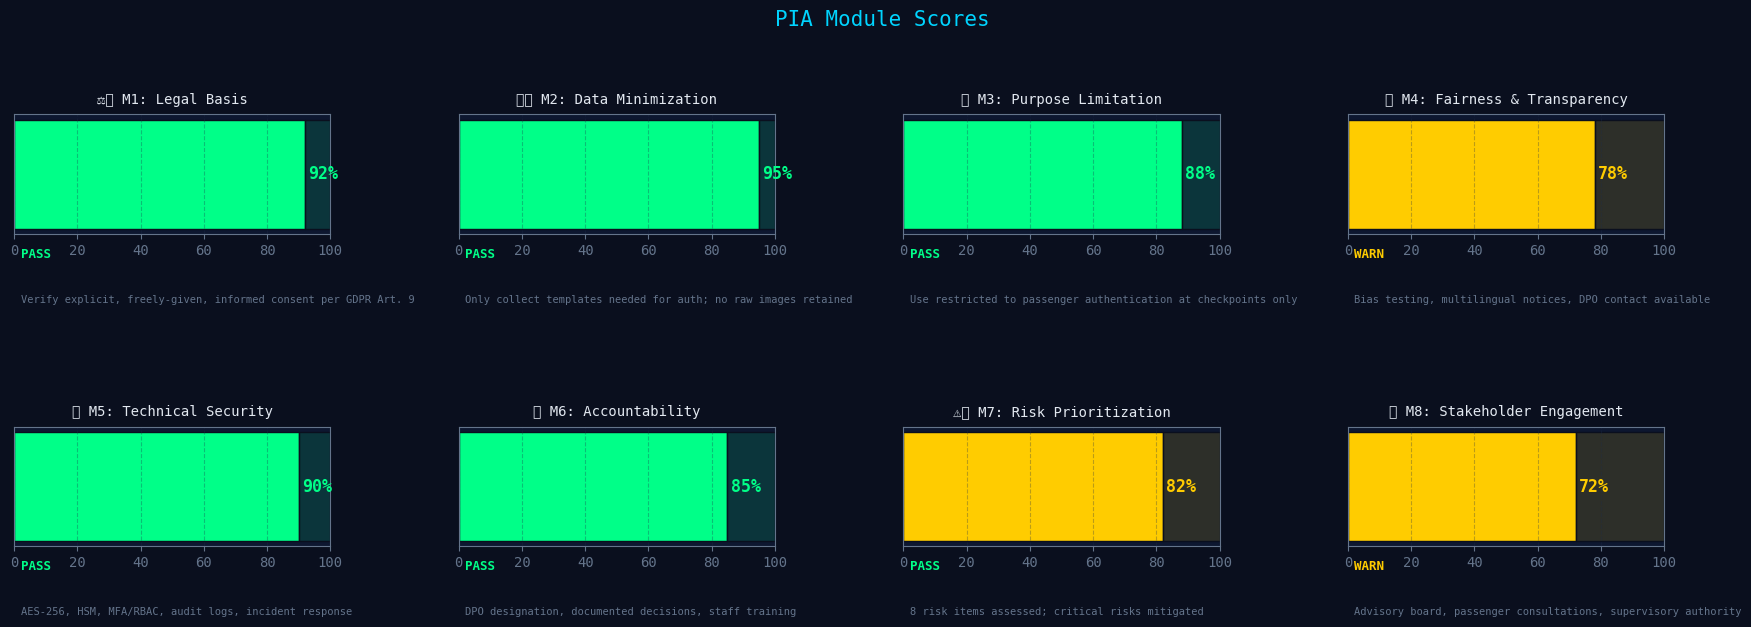


════════════════════════════════════════════════════════════════════════════════
  MODULE DETAIL NOTES
════════════════════════════════════════════════════════════════════════════════
  ✅  M1: Legal Basis (92%)
      Consent collected at enrollment. Non-self-selected passengers NOT captured. Freely given (equal queues). Withdrawable anytime. Consent log maintained.

  ✅  M2: Data Minimization (95%)
      Templates only (never raw images). Deleted after auth (S1) or on schedule (S2). No secondary inferences. Minimum identifiers stored.

  ✅  M3: Purpose Limitation (88%)
      Strict purpose limitation. Technical isolation from surveillance/LE DB. Regular audits for scope creep.

  ⚠️  M4: Fairness & Transparency (78%)
      Quarterly bias testing scheduled. Multilingual notices at 12 checkpoints. Human review on false rejections. Advisory board engagement pending.

  ✅  M5: Technical Security (90%)
      AES-256 at rest, TLS 1.2+ in transit. HSM key management. MFA+RBAC for all staff. 

In [ ]:
pia_modules = [
    {"id":1,"name":"Legal Basis","icon":"⚖️","score":92,"status":"PASS",
     "desc":"Verify explicit, freely-given, informed consent per GDPR Art. 9",
     "detail":"Consent collected at enrollment. Non-self-selected passengers NOT captured. Freely given (equal queues). Withdrawable anytime. Consent log maintained."},
    {"id":2,"name":"Data Minimization","icon":"🗜️","score":95,"status":"PASS",
     "desc":"Only collect templates needed for auth; no raw images retained",
     "detail":"Templates only (never raw images). Deleted after auth (S1) or on schedule (S2). No secondary inferences. Minimum identifiers stored."},
    {"id":3,"name":"Purpose Limitation","icon":"🎯","score":88,"status":"PASS",
     "desc":"Use restricted to passenger authentication at checkpoints only",
     "detail":"Strict purpose limitation. Technical isolation from surveillance/LE DB. Regular audits for scope creep."},
    {"id":4,"name":"Fairness & Transparency","icon":"🔍","score":78,"status":"WARN",
     "desc":"Bias testing, multilingual notices, DPO contact available",
     "detail":"Quarterly bias testing scheduled. Multilingual notices at 12 checkpoints. Human review on false rejections. Advisory board engagement pending."},
    {"id":5,"name":"Technical Security","icon":"🔐","score":90,"status":"PASS",
     "desc":"AES-256, HSM, MFA/RBAC, audit logs, incident response",
     "detail":"AES-256 at rest, TLS 1.2+ in transit. HSM key management. MFA+RBAC for all staff. Encrypted audit logs. IDS active."},
    {"id":6,"name":"Accountability","icon":"📋","score":85,"status":"PASS",
     "desc":"DPO designation, documented decisions, staff training",
     "detail":"DPO designated with independence. DPIA submitted. Staff training completed. DSAR process documented (30-day SLA)."},
    {"id":7,"name":"Risk Prioritization","icon":"⚠️","score":82,"status":"PASS",
     "desc":"8 risk items assessed; critical risks mitigated",
     "detail":"All 8 risks assessed. 5 fully mitigated. 3 under ongoing monitoring. Risk matrix maintained. Supervisory authority informed."},
    {"id":8,"name":"Stakeholder Engagement","icon":"👥","score":72,"status":"WARN",
     "desc":"Advisory board, passenger consultations, supervisory authority",
     "detail":"Advisory board established. 2/4 passenger consultations completed. Supervisory authority active. Next advisory board meeting: Mar 2026."},
]

def show_pia():
    overall = int(np.mean([m['score'] for m in pia_modules]))
    passed  = sum(1 for m in pia_modules if m['status']=='PASS')
    display(HTML(f"""
    <div style='background:#0a0f1e;padding:20px;border-radius:12px;font-family:monospace;margin-bottom:16px'>
      <div style='color:#00d4ff;font-size:16px;font-weight:bold;margin-bottom:14px'>📋 PRIVACY IMPACT ASSESSMENT — 8-MODULE FRAMEWORK</div>
      <div style='display:flex;gap:14px;flex-wrap:wrap'>
        <div style='background:#111827;border:1px solid #1e2d4a;border-radius:10px;padding:14px 20px;flex:1;min-width:140px'>
          <div style='color:#64748b;font-size:11px;text-transform:uppercase;letter-spacing:1px'>Overall Score</div>
          <div style='font-size:28px;font-weight:bold;color:#00ff88'>{overall}%</div>
        </div>
        <div style='background:#111827;border:1px solid #1e2d4a;border-radius:10px;padding:14px 20px;flex:1;min-width:140px'>
          <div style='color:#64748b;font-size:11px;text-transform:uppercase;letter-spacing:1px'>Modules Passed</div>
          <div style='font-size:28px;font-weight:bold;color:#00d4ff'>{passed}/8</div>
        </div>
        <div style='background:#111827;border:1px solid #1e2d4a;border-radius:10px;padding:14px 20px;flex:1;min-width:140px'>
          <div style='color:#64748b;font-size:11px;text-transform:uppercase;letter-spacing:1px'>DPIA Status</div>
          <div style='font-size:22px;font-weight:bold;color:#00ff88'>Submitted</div>
        </div>
        <div style='background:#111827;border:1px solid #1e2d4a;border-radius:10px;padding:14px 20px;flex:1;min-width:140px'>
          <div style='color:#64748b;font-size:11px;text-transform:uppercase;letter-spacing:1px'>Next Review</div>
          <div style='font-size:22px;font-weight:bold;color:#a855f7'>Aug 2026</div>
        </div>
      </div>
    </div>
    """))

    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    fig.patch.set_facecolor(C['bg'])
    fig.suptitle("PIA Module Scores", color=C['accent'], fontsize=15, y=1.01)

    for i, m in enumerate(pia_modules):
        ax = axes[i//4][i%4]
        color = C['green'] if m['score'] >= 85 else C['yellow']
        ax.barh([m['name']], [m['score']], color=color, height=0.55, edgecolor=C['bg'])
        ax.barh([m['name']], [100 - m['score']], left=[m['score']], color=color+'22', height=0.55, edgecolor=C['bg'])
        ax.set_xlim(0,100)
        ax.text(m['score']+1, 0, f"{m['score']}%", va='center', color=color, fontsize=12, fontweight='bold')
        ax.set_title(f"{m['icon']} M{m['id']}: {m['name']}", color=C['text'], fontsize=10, pad=8)
        badge_color = C['green'] if m['status']=='PASS' else C['yellow']
        ax.text(2, -0.42, m['status'], color=badge_color, fontsize=9, fontweight='bold')
        ax.text(2, -0.65, m['desc'], color=C['muted'], fontsize=7.5)
        ax.set_yticks([])
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout(pad=2)
    plt.savefig("pia_framework.png", dpi=120, bbox_inches='tight', facecolor=C['bg'])
    plt.show()

    # Module detail table
    print("\n" + "═"*80)
    print("  MODULE DETAIL NOTES")
    print("═"*80)
    for m in pia_modules:
        status_icon = "✅" if m['status']=='PASS' else "⚠️"
        print(f"  {status_icon}  M{m['id']}: {m['name']} ({m['score']}%)")
        print(f"      {m['detail']}")
        print()

show_pia()
